<a href="https://colab.research.google.com/github/dasumi1/Entregas-IA/blob/main/Trabalho_Previs%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [751]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SHEET_ID = "1gak9eqEBcgFOzP1uPjVi__X3tfKDdEFec77nUFLcWpc"
GID = "822446140"  # aba Página1
url_tsv = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=tsv&gid={GID}"

# TSV + vírgula decimal
df = pd.read_csv(url_tsv, sep="\t", decimal=",")

print("Colunas lidas:", list(df.columns))
display(df.head())

Colunas lidas: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'Happiness_Class']


,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Happiness_Class
0,Denmark,Western Europe,1,7.526,7.46,7.592,144.178,116.374,79.504,57.941,44.453,36.171,273.939,Alto
1,Switzerland,Western Europe,2,7.509,7.428,7.59,152.733,114.524,86.303,58.557,41.203,28.083,269.463,Alto
2,Iceland,Western Europe,3,7.501,7.333,7.669,142.666,118.326,86.733,56.624,14.975,47.678,283.137,Alto
3,Norway,Western Europe,4,7.498,7.421,7.575,157.744,1.1269,79.579,59.609,35.776,37.895,266.465,Alto
4,Finland,Western Europe,5,7.413,7.351,7.475,140.598,113.464,81.091,57.104,41.004,25.492,282.596,Alto


In [752]:
#FEATURES = ["Economy (GDP per Capita)", "Health (Life Expectancy)", "Freedom"]
FEATURE_SETS = {
    "BC":  ["Economy (GDP per Capita)", "Health (Life Expectancy)"],              # colunas B,C
    "BD":  ["Economy (GDP per Capita)", "Freedom"],             # colunas B,D
    "CD":  ["Health (Life Expectancy)", "Freedom"],            # colunas C,D
    "BCD": ["Economy (GDP per Capita)", "Health (Life Expectancy)", "Freedom"] # colunas B,C,D
}
FEATURES = FEATURE_SETS["BD"]   # <-- troque aqui: "BC", "BD", "CD", "BCD"

TARGET = "Happiness_Class"            # coluna N (classe)

for col in FEATURES + ["Happiness Rank"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Normaliza o target e remove linhas inválidas
df[TARGET] = df[TARGET].astype(str).str.strip().str.lower()
df = df.dropna(subset=FEATURES + [TARGET]).copy() #remove linhas com valores inválidos

print("\nDistribuição do target:")
print(df[TARGET].value_counts())



Distribuição do target:
Happiness_Class
baixo    58
medio    52
alto     47
Name: count, dtype: int64


In [753]:
le = LabelEncoder()
y_all = le.fit_transform(df[TARGET])
X_all = df[FEATURES].values

print("\nClasses:", list(le.classes_))
print("Total linhas válidas:", len(df))


Classes: ['alto', 'baixo', 'medio']
Total linhas válidas: 157


In [754]:

RANDOM_STATE = 42
df_shuffled = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
limite_teste=int(len(df)*0.20) # Split : 20% teste + 80% treino
test_df  = df_shuffled.iloc[:limite_teste].copy()
train_df = df_shuffled.iloc[limite_teste:len(df)].copy()
X_train = train_df[FEATURES].values
y_train = le.transform(train_df[TARGET])
X_test  = test_df[FEATURES].values
y_test  = le.transform(test_df[TARGET])
print("\nTreino:", len(train_df), "| Teste:", len(test_df))



Treino: 126 | Teste: 31


In [755]:
def dist_classes(frame, target_col, titulo):
    vc = frame[target_col].value_counts(dropna=False)
    pct = (vc / len(frame) * 100).round(1)
    out = pd.DataFrame({"qtd": vc, "%": pct})
    print(f"\n=== {titulo} (n={len(frame)}) ===")
    display(out)

dist_classes(df, TARGET, "Dataset completo")
dist_classes(train_df, TARGET, "Treino")
dist_classes(test_df, TARGET, "Teste")


=== Dataset completo (n=157) ===


,qtd,%
Happiness_Class,,
baixo,58,36.9
medio,52,33.1
alto,47,29.9



=== Treino (n=126) ===


,qtd,%
Happiness_Class,,
baixo,46,36.5
medio,43,34.1
alto,37,29.4



=== Teste (n=31) ===


,qtd,%
Happiness_Class,,
baixo,12,38.7
alto,10,32.3
medio,9,29.0


In [756]:
# Modelo KNN
K = 15

WEIGHTS = "distance"  # "uniform" ou "distance"

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=K, weights=WEIGHTS))
])

model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(n_neighbors=15, weights='distance'))])

In [757]:
# Avaliação

y_pred = model.predict(X_test)

print("\nFeatures usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred))



Features usadas: ['Economy (GDP per Capita)', 'Freedom']
Acurácia: 0.7419354838709677

Relatório:
              precision    recall  f1-score   support

        alto       0.89      0.80      0.84        10
       baixo       0.88      0.58      0.70        12
       medio       0.57      0.89      0.70         9

    accuracy                           0.74        31
   macro avg       0.78      0.76      0.75        31
weighted avg       0.79      0.74      0.74        31

Matriz de confusão (real x previsto):
[[8 1 1]
 [0 7 5]
 [1 0 8]]


In [758]:
# Resultado detalhado do teste
test_df["classe_prevista"] = le.inverse_transform(y_pred)
display(test_df[["Country", "Region"] + FEATURES + [TARGET, "classe_prevista"]])

,Country,Region,Economy (GDP per Capita),Freedom,Happiness_Class,classe_prevista
0,Congo (Brazzaville),Sub-Saharan Africa,77.1090,37.938,baixo,baixo
1,El Salvador,Latin America and Caribbean,8.7370,37.269,alto,medio
2,Gabon,Sub-Saharan Africa,115.8510,28.098,baixo,medio
3,Ivory Coast,Sub-Saharan Africa,55.5070,40.663,baixo,baixo
4,Iraq,Middle East and Northern Africa,107.4740,24.856,baixo,medio
5,Malta,Western Europe,130.7820,54.994,alto,alto
6,Vietnam,Southeastern Asia,74.0370,55.954,medio,medio
7,Tunisia,Middle East and Northern Africa,97.7240,23.553,medio,medio
8,Macedonia,Central and Eastern Europe,1.0193,27.668,medio,medio
9,Cambodia,Southeastern Asia,55.6040,58.852,baixo,baixo



=== Árvore de decisão ===
Features usadas: ['Economy (GDP per Capita)', 'Freedom']
Acurácia: 0.7096774193548387

Relatório:
              precision    recall  f1-score   support

        alto       0.90      0.90      0.90        10
       baixo       0.83      0.42      0.56        12
       medio       0.53      0.89      0.67         9

    accuracy                           0.71        31
   macro avg       0.76      0.74      0.71        31
weighted avg       0.77      0.71      0.70        31

Matriz de confusão (real x previsto):
[[9 1 0]
 [0 5 7]
 [1 0 8]]


,Country,Region,Economy (GDP per Capita),Freedom,Happiness_Class,classe_prevista_arvore
0,Congo (Brazzaville),Sub-Saharan Africa,77.1090,37.938,baixo,medio
1,El Salvador,Latin America and Caribbean,8.7370,37.269,alto,baixo
2,Gabon,Sub-Saharan Africa,115.8510,28.098,baixo,medio
3,Ivory Coast,Sub-Saharan Africa,55.5070,40.663,baixo,baixo
4,Iraq,Middle East and Northern Africa,107.4740,24.856,baixo,medio
5,Malta,Western Europe,130.7820,54.994,alto,alto
6,Vietnam,Southeastern Asia,74.0370,55.954,medio,medio
7,Tunisia,Middle East and Northern Africa,97.7240,23.553,medio,medio
8,Macedonia,Central and Eastern Europe,1.0193,27.668,medio,medio
9,Cambodia,Southeastern Asia,55.6040,58.852,baixo,baixo


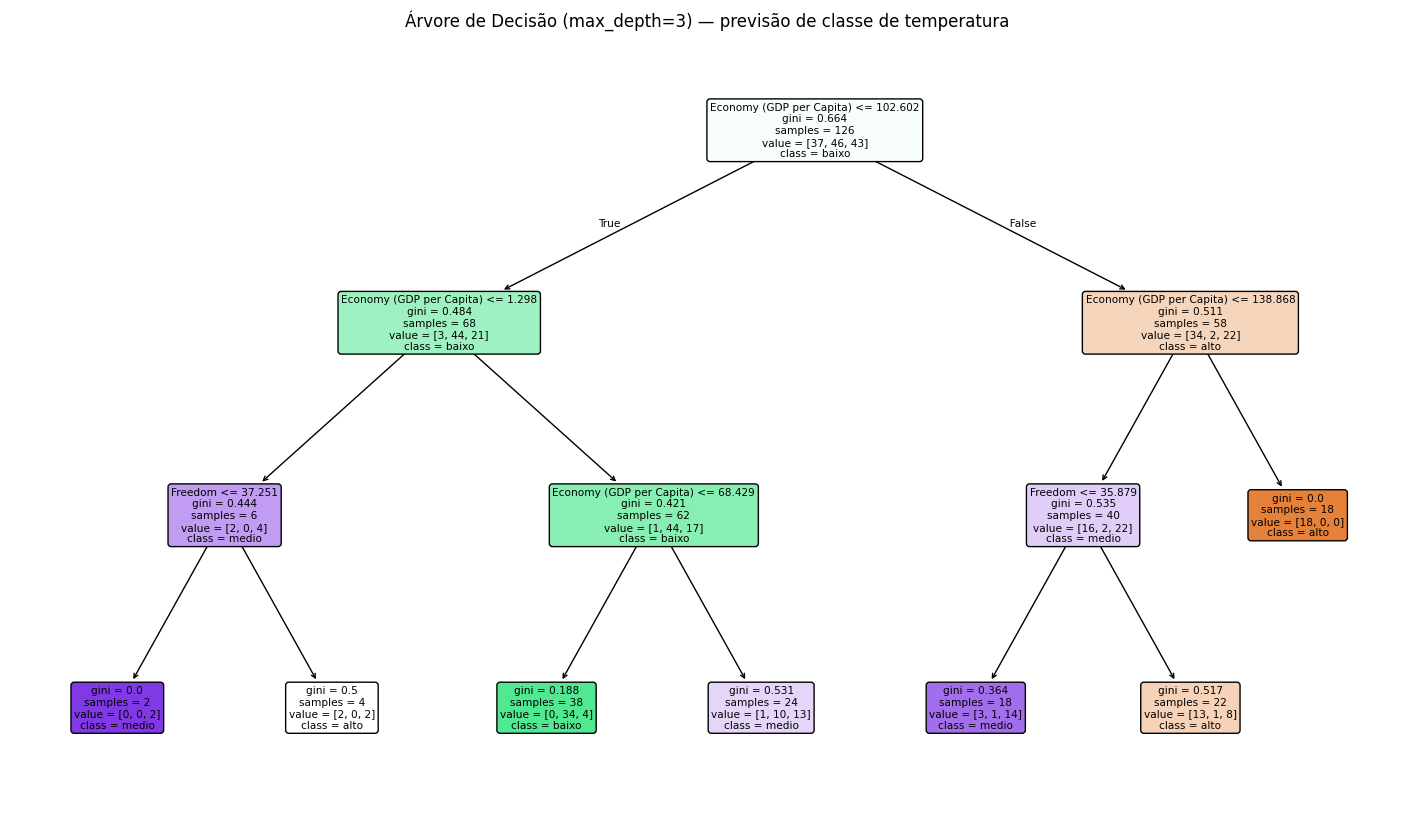

In [759]:
# ========= Árvore de decisão (usando as MESMAS variáveis do seu Colab) =========
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# "simples" e legível para aula (ajuste se quiser):
tree = DecisionTreeClassifier(
    max_depth=3,          # controla complexidade/legibilidade
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("\n=== Árvore de decisão ===")
print("Features usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred_tree))
print("\nRelatório:")
print(classification_report(y_test, y_pred_tree, target_names=le.classes_))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred_tree))

# Resultado detalhado do teste (sem mudar sua tabela do KNN, usa outra coluna)
test_df["classe_prevista_arvore"] = le.inverse_transform(y_pred_tree)
display(test_df[["Country", "Region"] + FEATURES + [TARGET, "classe_prevista_arvore"]])

# desenhar a árvore
plt.figure(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=list(le.classes_),
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Árvore de Decisão (max_depth=3) — previsão de classe de temperatura")
plt.show()